# 03_price_prediction.ipynb


**Mục tiêu:**


# Thư viện

In [1]:
import warnings
warnings.simplefilter('ignore')

import json
import joblib
import sys
import time
from datetime import datetime
from pathlib import Path
from IPython.display import Markdown, display

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
import shap

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.feature_selection import f_regression, mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from scipy import sparse
from scipy.stats import kruskal, spearmanr

from optuna.importance import get_param_importances
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    root_mean_squared_error = None

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError as error:
    XGBRegressor = None
    XGBOOST_AVAILABLE = False
    XGBOOST_IMPORT_ERROR = error

try:
    from catboost import CatBoostRegressor
    CATBOOST_AVAILABLE = True
except ImportError as error:
    CatBoostRegressor = None
    CATBOOST_AVAILABLE = False
    CATBOOST_IMPORT_ERROR = error


def find_project_root(start_path=None):
    """Find the repository root without depending on the notebook working directory."""
    current_path = Path(start_path or Path.cwd()).resolve()
    for candidate in [current_path, *current_path.parents]:
        if (
            (candidate / "pyproject.toml").exists()
            and (candidate / "README.md").exists()
        ) or (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Project root could not be found from the current directory.")


PROJECT_ROOT = find_project_root()
TARGET = "log_price"
TEST_SIZE = 0.2
N_SPLITS = 5
RANDOM_STATE = 42
RUN_STARTED_AT = datetime.now().isoformat(timespec="seconds")

N_TRIALS_HGBR = 30
N_TRIALS_XGB = 30
EARLY_STOPPING_ROUNDS = 50
HGB_N_ITER_NO_CHANGE = 20
HGB_MAX_ITER = 1000
XGB_MAX_ESTIMATORS = 2000
TUNING_TIMEOUT = None
N_JOBS = -1

EXPLAIN_RANDOM_STATE = 42
PERMUTATION_SAMPLE_SIZE = 2000
PERMUTATION_REPEATS = 5
SHAP_SAMPLE_SIZE = 1000
SHAP_BACKGROUND_SIZE = 200
TOP_N_IMPORTANCE = 15
N_DEPENDENCE_FEATURES = 3
N_LOCAL_EXPLANATIONS = 3
EXPLAIN_N_JOBS = -1

PRICE_MODELING_OUTPUT_DIR = PROJECT_ROOT / "ml" / "outputs" / "price_modeling"
OUTPUT_DIRS = {
    "csv": PRICE_MODELING_OUTPUT_DIR / "csv",
    "charts": PRICE_MODELING_OUTPUT_DIR / "charts",
    "models": PRICE_MODELING_OUTPUT_DIR / "models",
    "metadata": PRICE_MODELING_OUTPUT_DIR / "metadata",
}

for output_dir in OUTPUT_DIRS.values():
    output_dir.mkdir(parents=True, exist_ok=True)


def format_output_path(output_path):
    return output_path.relative_to(PROJECT_ROOT).as_posix()


def save_dataframe(dataframe, filename):
    output_path = OUTPUT_DIRS["csv"] / filename
    dataframe.to_csv(output_path, index=False, encoding="utf-8-sig")
    print(f"Saved: {format_output_path(output_path)}")
    return output_path


def save_figure(filename, figure=None):
    output_path = OUTPUT_DIRS["charts"] / filename
    if figure is not None:
        plt.figure(figure.number)
    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )
    print(f"Saved: {format_output_path(output_path)}")
    return output_path


def json_default(value):
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, pd.Series):
        return value.to_dict()
    if isinstance(value, pd.DataFrame):
        return value.to_dict(orient="records")
    if isinstance(value, Path):
        return value.as_posix()
    return str(value)


def save_json(data, filename):
    output_path = OUTPUT_DIRS["metadata"] / filename
    with output_path.open("w", encoding="utf-8") as file:
        json.dump(
            data,
            file,
            indent=4,
            ensure_ascii=False,
            default=json_default,
        )
    print(f"Saved: {format_output_path(output_path)}")
    return output_path


print(f"Project root: {PROJECT_ROOT}")
print(f"Output root: {format_output_path(PRICE_MODELING_OUTPUT_DIR)}")


Project root: D:\Projects\Y2026_Sources\airbnb-analytics-platform
Output root: ml/outputs/price_modeling


# Dữ liệu

In [2]:
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.motherduck import connect_motherduck
from utils.sql import query_dataframe

connection = connect_motherduck(read_only=True)


In [5]:
df_model = query_dataframe(
    connection,
    """
    select *
    from airbnb_analytics.gold.gold_price_model_features
    """
)

print("Kích thước dữ liệu:", df_model.shape)
df_model.head()

Kích thước dữ liệu: (23273, 33)


,listing_id,host_id,neighbourhood,property_type,room_type,price,accommodates,bathrooms,bedrooms,beds,...,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,has_reviews,amenities_count,log_price
0,156583,58920,Bang Rak,Entire rental unit,Entire home/apt,1248.0,2,1.0,1.0,1.0,...,4.24,4.54,4.33,4.24,4.18,4.37,4.24,1,46,7.130099
1,169514,729617,Vadhana,Entire rental unit,Entire home/apt,1498.0,2,2.0,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,15,7.312553
2,449826,2129668,Bang Kho laen,Entire loft,Entire home/apt,762.0,2,1.0,1.0,1.0,...,4.64,4.71,4.69,4.80,4.83,4.15,4.54,1,22,6.637258
3,818612,822284,Bang Sue,Entire guesthouse,Entire home/apt,1300.0,3,1.0,1.0,2.0,...,5.00,4.94,4.89,4.94,5.00,4.67,5.00,1,29,7.170888
4,885848,4696220,Ratchathewi,Entire rental unit,Entire home/apt,1386.0,2,1.0,1.0,3.0,...,4.78,4.92,4.88,4.92,4.96,4.50,4.54,1,46,7.234898


## Hàm xử lý cố định

**Mục tiêu:**
- Do `property_type` có 74 giá trị gây khó khăn cho quá trình Encoding, vì vậy, thực hiện gom nhóm property theo loại tài sản nhằm giảm số lượng cột khi thực hiện One-Hot Encoding.
- Điền khuyến 0 cho `review_per_month`

In [6]:
def group_property_type(value):
    """Gom property_type thành property_base_group."""

    if pd.isna(value):
        return "Unknown"

    text = str(value).lower().strip()

    if any(k in text for k in ["serviced apartment", "aparthotel"]):
        return "Serviced Apartment / Aparthotel"

    if "hostel" in text:
        return "Hostel"

    if any(k in text for k in [
        "guesthouse", "guest house", "bed and breakfast"
    ]):
        return "Guesthouse / B&B"

    if any(k in text for k in [
        "hotel", "resort", "ryokan", "kezhan"
    ]):
        return "Hotel / Resort"

    if "villa" in text:
        return "Villa"

    if "loft" in text:
        return "Loft"

    if any(k in text for k in [
        "rental unit", "condo", "apartment"
    ]):
        return "Apartment / Condo"

    if any(k in text for k in [
        "treehouse", "tiny home", "earthen home",
        "earth home", "dome", "tower", "lighthouse",
        "castle", "shipping container", "container",
        "hut", "tent"
    ]):
        return "Unique Stay"

    if any(k in text for k in [
        "cabin", "nature lodge", "farm stay", "barn",
        "houseboat", "boat", "island", "camper/rv"
    ]):
        return "Special Stay"

    if any(k in text for k in [
        "townhouse", "guest suite", "vacation home",
        "casa particular", "bungalow", "cottage",
        "chalet", "house", "home"
    ]):
        return "House / Home"

    return "Other"


def prepare_features(df):
    """
    Xử lý cố định trước khi chia train/test:
    - Gom property_type thành property_base_group
    - Gán reviews_per_month = 0 cho listing không có review
    """

    data = df.copy()

    # Gom loại tài sản
    data["property_base_group"] = (
        data["property_type"]
        .apply(group_property_type)
    )

    # Bỏ property_type gốc
    data = data.drop(
        columns=["property_type"],
        errors="ignore"
    )

    # Listing không có review thì reviews_per_month = 0
    if {"has_reviews", "reviews_per_month"}.issubset(data.columns):
        data.loc[
            data["has_reviews"] == 0,
            "reviews_per_month"
        ] = 0

    return data

In [7]:
# Áp dụng
df_model = prepare_features(df_model)

display(
    df_model["property_base_group"]
    .value_counts()
    .to_frame("listing_count")
)

,listing_count
property_base_group,
Apartment / Condo,16731
House / Home,3066
Hotel / Resort,1565
Serviced Apartment / Aparthotel,640
Guesthouse / B&B,455
Hostel,361
Loft,180
Villa,97
Unique Stay,90


## Xác định biến đầu vào và biến mục tiêu

In [8]:
# Tách biến mục tiêu
y = df_model[TARGET].copy()

# Tách biến đầu vào
X = df_model.drop(
    columns=[TARGET] + ['listing_id', 'host_id']
).copy()

print("Kích thước X:", X.shape)
print("Kích thước y:", y.shape)


Kích thước X: (23273, 30)
Kích thước y: (23273,)


In [9]:
y.describe()

count    23273.000000
mean         7.327586
std          0.758660
min          1.609438
25%          6.828712
50%          7.229839
75%          7.699842
max         13.815512
Name: log_price, dtype: float64

In [10]:
feature_types = pd.DataFrame({
    "feature": X.columns,
    "dtype": X.dtypes.astype(str).values,
    "missing_count": X.isna().sum().values,
    "missing_rate": (
        X.isna().mean().mul(100).round(2).values
    ),
    "unique_count": X.nunique(dropna=True).values
})

save_dataframe(feature_types, "01_feature_quality_summary.csv")
feature_types


Saved: ml/outputs/price_modeling/csv/01_feature_quality_summary.csv


,feature,dtype,missing_count,missing_rate,unique_count
0,neighbourhood,str,0,0.00,50
1,room_type,str,0,0.00,4
2,price,float64,0,0.00,4489
3,accommodates,int32,0,0.00,16
4,bathrooms,float64,60,0.26,31
5,bedrooms,float64,88,0.38,20
6,beds,float64,53,0.23,32
7,minimum_nights,int32,0,0.00,83
8,maximum_nights,int32,0,0.00,136
9,instant_bookable,bool,0,0.00,2


In [11]:
# Phân nhóm các biến
numeric_features = X.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

boolean_features = X.select_dtypes(
    include=["bool", "boolean"]
).columns.tolist()

print("Biến số:", len(numeric_features))
print("Biến phân loại:", len(categorical_features))
print("Biến boolean:", len(boolean_features))

Biến số: 24
Biến phân loại: 4
Biến boolean: 2


# Chia tập dữ liệu

In [12]:
id_columns = [
    col for col in ["listing_id", "host_id"]
    if col in df_model.columns
]

# Lưu metadata riêng
metadata = df_model[id_columns].copy()

# Biến mục tiêu
y = df_model[TARGET].copy()

# Biến đầu vào, không chứa ID và target
X = df_model.drop(
    columns=[TARGET] + id_columns
).copy()

# Chia dữ liệu
X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X,
    y,
    metadata,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print("X train:", X_train.shape)
print("X test:", X_test.shape)
print("y train:", y_train.shape)
print("y test:", y_test.shape)


X train: (18618, 30)
X test: (4655, 30)
y train: (18618,)
y test: (4655,)


In [13]:
# Check log_price distribution in train and test sets
target_split_summary = pd.DataFrame({
    "train": y_train.describe(),
    "test": y_test.describe()
})

save_dataframe(
    target_split_summary.reset_index().rename(columns={"index": "statistic"}),
    "02_target_split_summary.csv",
)
target_split_summary


Saved: ml/outputs/price_modeling/csv/02_target_split_summary.csv


,train,test
count,18618.000000,4655.000000
mean,7.329772,7.318842
std,0.764662,0.734182
min,1.609438,4.812184
25%,6.830874,6.827629
50%,7.230563,7.229839
75%,7.702895,7.693482
max,13.815512,12.124694


**Nhận xét:** Tập train và test có phân phối log_price ***tương đối tương đồng*** về trung bình, trung vị, độ lệch chuẩn và các phân vị. Điều này cho thấy phép chia dữ liệu ngẫu nhiên giữ được cấu trúc phân phối chung của biến mục tiêu. Tuy nhiên, ***tập train chứa một số giá trị thấp*** không xuất hiện trong tập test, vì vậy cần tiếp tục theo dõi sai số ở các phân khúc giá thấp trong bước đánh giá mô hình.

# Pipeline tiền xử lý dữ liệu

**Tổng hợp pipeline tiền xử lý dữ liệu:**

| Nhóm biến | Biến | Cách xử lý |
|---|---|---|
| Biến mục tiêu | `price` | Loại các dòng có `price` thiếu, bằng 0 hoặc âm |
| Biến mục tiêu | `price` | Tạo `log_price = log1p(price)` và sử dụng `log_price` làm target |
| Định danh | `listing_id`, `host_id` | Loại khỏi tập feature, chỉ giữ lại để truy vết kết quả |
| Quy mô chỗ ở | `accommodates` | Giữ nguyên và kiểm tra các giá trị bất hợp lý |
| Quy mô chỗ ở | `bedrooms`, `bathrooms`, `beds` | Điền giá trị thiếu bằng median |
| Loại phòng | `room_type` | One-Hot Encoding |
| Loại tài sản | `property_type` | Gom từ 74 nhóm xuống khoảng 10–14 nhóm tài sản |
| Loại tài sản | `property_group` | One-Hot Encoding sau khi gom nhóm |
| Vị trí | `neighbourhood` | Giữ nguyên và One-Hot Encoding |
| Host | `host_response_rate`, `host_acceptance_rate` | Chuyển chuỗi phần trăm sang số trong khoảng `0–1` |
| Host | `host_response_rate`, `host_acceptance_rate` | Điền giá trị thiếu bằng median |
| Host | `host_response_time` | Điền giá trị thiếu bằng `"Unknown"` |
| Host | `host_response_time` | One-Hot Encoding |
| Host | `host_is_superhost` | Giá trị thiếu điền `0` |
| Host | `host_listings_count`, `host_total_listings_count` | Điền giá trị thiếu bằng median |
| Review | `number_of_reviews` | Giữ nguyên giá trị `0` |
| Review | `number_of_reviews_ltm` | Giữ nguyên giá trị `0` |
| Review | `reviews_per_month` | Điền `0` nếu listing chưa có review |
| Review | Các biến `review_scores_*` | Điền median và tạo cờ thiếu; có thể giữ NaN tự nhiên với CatBoost, XGBoost hoặc LightGBM |
| Review dẫn xuất | `has_reviews` | Tạo giá trị `1` nếu listing có review, ngược lại là `0` |
| Số đêm | `minimum_nights`, `maximum_nights` | Giữ nguyên, chưa áp dụng log-transform ở bước đầu |
| Biến số thông thường | `accommodates`, các biến tỷ lệ, khoảng cách | Áp dụng `StandardScaler` khi sử dụng mô hình tuyến tính hoặc KNN |
| Biến số thông thường | Các biến số | Không bắt buộc scale khi sử dụng Random Forest, XGBoost hoặc LightGBM |
| Biến phân loại hiếm | Category có tần suất rất thấp | Gom vào nhóm `"Other"` |

In [14]:
# =========================================================
# 1. KHAI BÁO NHÓM BIẾN
# =========================================================

numeric_features = [
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "amenities_count",
    "host_response_rate",
    "host_acceptance_rate",
    "host_listings_count",
    "host_total_listings_count",
    "calculated_host_listings_count"
]

review_count_features = [
    "number_of_reviews",
    "number_of_reviews_ltm",
    "reviews_per_month"
]

review_score_features = [
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value"
]

categorical_features = [
    "neighbourhood",
    "room_type",
    "property_base_group",
    "host_response_time"
]

binary_features = [
    "instant_bookable",
    "host_is_superhost",
    "has_reviews"
]


# Chỉ giữ các cột thực sự tồn tại trong X_train
def keep_existing_columns(columns, dataframe):
    return [col for col in columns if col in dataframe.columns]


numeric_features = keep_existing_columns(
    numeric_features,
    X_train
)

review_count_features = keep_existing_columns(
    review_count_features,
    X_train
)

review_score_features = keep_existing_columns(
    review_score_features,
    X_train
)

categorical_features = keep_existing_columns(
    categorical_features,
    X_train
)

binary_features = keep_existing_columns(
    binary_features,
    X_train
)


# =========================================================
# 2. PIPELINE BIẾN SỐ THÔNG THƯỜNG
# =========================================================
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# =========================================================
# 3. PIPELINE BIẾN ĐẾM REVIEW
# =========================================================
# number_of_reviews và number_of_reviews_ltm đã giữ giá trị 0 thật.
# reviews_per_month đã được gán 0 khi listing không có review.
# Median chỉ xử lý các trường hợp thiếu bất thường còn lại.

review_count_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# =========================================================
# 4. PIPELINE REVIEW SCORE CHO MODEL KHÔNG HỖ TRỢ NaN
# =========================================================
review_score_imputed_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# =========================================================
# 5. PIPELINE BIẾN PHÂN LOẠI
# =========================================================
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Unknown"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=30,
                sparse_output=True
            )
        )
    ]
)


# =========================================================
# 6. PIPELINE BIẾN NHỊ PHÂN
# =========================================================
binary_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        )
    ]
)


# =========================================================
# 7. PREPROCESSOR CHO MODEL KHÔNG HỖ TRỢ MISSING
# =========================================================
# Dùng cho:
# Linear Regression, Ridge, Lasso, KNN,
# Random Forest và các model sklearn thông thường.

preprocessor_imputed = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "review_count",
            review_count_pipeline,
            review_count_features
        ),
        (
            "review_score",
            review_score_imputed_pipeline,
            review_score_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        ),
        (
            "binary",
            binary_pipeline,
            binary_features
        )
    ],
    remainder="drop"
)


# =========================================================
# 8. PREPROCESSOR CHO MODEL HỖ TRỢ NATIVE MISSING
# =========================================================
# Dùng cho XGBoost hoặc LightGBM.
# review_scores_* được giữ nguyên NaN để model tự xử lý.

preprocessor_native_missing = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "review_count",
            review_count_pipeline,
            review_count_features
        ),
        (
            "review_score",
            "passthrough",
            review_score_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        ),
        (
            "binary",
            binary_pipeline,
            binary_features
        )
    ],
    remainder="drop"
)


# =========================================================
# 9. KIỂM TRA NHÓM BIẾN
# =========================================================
print("Numeric features:", numeric_features)
print("Review count features:", review_count_features)
print("Review score features:", review_score_features)
print("Categorical features:", categorical_features)
print("Binary features:", binary_features)

Numeric features: ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'amenities_count', 'host_response_rate', 'host_acceptance_rate', 'host_listings_count', 'host_total_listings_count', 'calculated_host_listings_count']
Review count features: ['number_of_reviews', 'number_of_reviews_ltm', 'reviews_per_month']
Review score features: ['review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value']
Categorical features: ['neighbourhood', 'room_type', 'property_base_group', 'host_response_time']
Binary features: ['instant_bookable', 'host_is_superhost', 'has_reviews']


# Baseline mô hình hồi quy giá

Phần này chỉ dùng `X_train` và `y_train` để đánh giá baseline bằng 5-fold Cross-Validation. `X_test` và `y_test` được giữ riêng cho bước đánh giá cuối.

In [15]:
cv = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

if not XGBOOST_AVAILABLE:
    print(f"Không import được xgboost: {XGBOOST_IMPORT_ERROR}")

if not CATBOOST_AVAILABLE:
    print(f"Không import được catboost: {CATBOOST_IMPORT_ERROR}")


## Hàm tính metric và số feature sau preprocessing

Adjusted R² dùng số feature thực tế sau khi preprocessor đã fit trong từng fold.

In [16]:
def calculate_rmse(y_true, y_pred):
    if root_mean_squared_error is not None:
        return root_mean_squared_error(y_true, y_pred)
    return np.sqrt(mean_squared_error(y_true, y_pred))


def calculate_adjusted_r2(r2, n_observations, n_features):
    if n_observations <= n_features + 1:
        return np.nan
    return 1 - (1 - r2) * (n_observations - 1) / (
        n_observations - n_features - 1
    )


def get_pipeline_n_features(fitted_pipeline, X_validation):
    if hasattr(fitted_pipeline, "named_steps") and "preprocessor" in fitted_pipeline.named_steps:
        transformed = fitted_pipeline.named_steps["preprocessor"].transform(X_validation)
        return transformed.shape[1]

    if hasattr(fitted_pipeline, "n_features_in_"):
        return fitted_pipeline.n_features_in_

    return X_validation.shape[1]


def make_failed_fold_row(model_name, fold_number, train_index, validation_index, error):
    return {
        "model": model_name,
        "fold": fold_number,
        "n_train": len(train_index),
        "n_validation": len(validation_index),
        "n_features": np.nan,
        "mae": np.nan,
        "rmse": np.nan,
        "r2": np.nan,
        "adjusted_r2": np.nan,
        "fit_time_seconds": np.nan,
        "predict_time_seconds": np.nan,
        "status": "failed",
        "error_message": str(error)
    }

## Hàm đánh giá K-Fold cho pipeline sklearn

Mỗi fold tự fit toàn bộ preprocessing bên trong pipeline để tránh data leakage.

In [17]:
def evaluate_model_cv(model_name, pipeline, X_train, y_train, cv):
    fold_rows = []
    prediction_rows = []

    for fold_number, (train_index, validation_index) in enumerate(
        cv.split(X_train, y_train),
        start=1
    ):
        X_fold_train = X_train.iloc[train_index]
        X_fold_validation = X_train.iloc[validation_index]
        y_fold_train = y_train.iloc[train_index]
        y_fold_validation = y_train.iloc[validation_index]
        fitted_pipeline = clone(pipeline)

        try:
            fit_start = time.perf_counter()
            fitted_pipeline.fit(X_fold_train, y_fold_train)
            fit_time = time.perf_counter() - fit_start

            n_features = get_pipeline_n_features(
                fitted_pipeline,
                X_fold_validation
            )

            predict_start = time.perf_counter()
            y_pred = fitted_pipeline.predict(X_fold_validation)
            predict_time = time.perf_counter() - predict_start

            mae = mean_absolute_error(y_fold_validation, y_pred)
            rmse = calculate_rmse(y_fold_validation, y_pred)
            r2 = r2_score(y_fold_validation, y_pred)
            adjusted_r2 = calculate_adjusted_r2(
                r2,
                len(y_fold_validation),
                n_features
            )

            if np.isnan(adjusted_r2):
                print(
                    f"[{model_name}] Fold {fold_number}/{N_SPLITS} | "
                    "Adjusted R² không hợp lệ vì n <= p + 1"
                )

            fold_rows.append({
                "model": model_name,
                "fold": fold_number,
                "n_train": len(train_index),
                "n_validation": len(validation_index),
                "n_features": n_features,
                "mae": mae,
                "rmse": rmse,
                "r2": r2,
                "adjusted_r2": adjusted_r2,
                "fit_time_seconds": fit_time,
                "predict_time_seconds": predict_time,
                "status": "success",
                "error_message": ""
            })

            prediction_rows.append(pd.DataFrame({
                "model": model_name,
                "fold": fold_number,
                "row_index": y_fold_validation.index,
                "actual_log_price": y_fold_validation.to_numpy(),
                "predicted_log_price": y_pred,
                "residual": y_fold_validation.to_numpy() - y_pred,
                "absolute_error": np.abs(y_fold_validation.to_numpy() - y_pred)
            }))

            print(
                f"[{model_name}] Fold {fold_number}/{N_SPLITS} | "
                f"MAE={mae:.4f} | RMSE={rmse:.4f} | "
                f"R2={r2:.4f} | Adj.R2={adjusted_r2:.4f}"
            )

        except Exception as error:
            fold_rows.append(
                make_failed_fold_row(
                    model_name,
                    fold_number,
                    train_index,
                    validation_index,
                    error
                )
            )
            print(f"[{model_name}] Fold {fold_number}/{N_SPLITS} lỗi: {error}")

    return fold_rows, prediction_rows

## Pipeline baseline

DummyRegressor, Ridge và RandomForest dùng `preprocessor_imputed`. HistGradientBoosting và XGBoost dùng `preprocessor_native_missing`; riêng HistGradientBoosting ép output về dense.

In [18]:
preprocessor_hgb_dense = clone(preprocessor_native_missing)
preprocessor_hgb_dense.set_params(sparse_threshold=0.0)

baseline_pipelines = {
    "DummyRegressor": Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor_imputed)),
            ("model", DummyRegressor(strategy="median"))
        ]
    ),
    "Ridge": Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor_imputed)),
            ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE))
        ]
    ),
    "RandomForestRegressor": Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor_imputed)),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=300,
                    max_depth=None,
                    min_samples_leaf=1,
                    n_jobs=-1,
                    random_state=RANDOM_STATE
                )
            )
        ]
    ),
    "HistGradientBoostingRegressor": Pipeline(
        steps=[
            ("preprocessor", preprocessor_hgb_dense),
            (
                "model",
                HistGradientBoostingRegressor(
                    learning_rate=0.1,
                    max_iter=200,
                    random_state=RANDOM_STATE
                )
            )
        ]
    )
}

if XGBOOST_AVAILABLE:
    baseline_pipelines["XGBRegressor"] = Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor_native_missing)),
            (
                "model",
                XGBRegressor(
                    n_estimators=300,
                    learning_rate=0.05,
                    max_depth=6,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    objective="reg:squarederror",
                    n_jobs=-1,
                    random_state=RANDOM_STATE
                )
            )
        ]
    )

list(baseline_pipelines.keys())

['DummyRegressor',
 'Ridge',
 'RandomForestRegressor',
 'HistGradientBoostingRegressor',
 'XGBRegressor']

## Hàm đánh giá CatBoost

CatBoost không dùng One-Hot Encoding. Categorical được giữ dạng chuỗi, missing categorical điền `Unknown`, còn `review_scores_*` được giữ NaN.

In [19]:
def prepare_catboost_fold_data(X_fold_train, X_fold_validation):
    catboost_columns = keep_existing_columns(
        numeric_features
        + review_count_features
        + review_score_features
        + categorical_features
        + binary_features,
        X_fold_train
    )

    X_train_cb = X_fold_train[catboost_columns].copy()
    X_validation_cb = X_fold_validation[catboost_columns].copy()

    categorical_cols = keep_existing_columns(categorical_features, X_train_cb)
    median_impute_cols = keep_existing_columns(
        numeric_features + review_count_features,
        X_train_cb
    )
    review_score_cols = keep_existing_columns(review_score_features, X_train_cb)
    binary_cols = keep_existing_columns(binary_features, X_train_cb)

    for col in categorical_cols:
        X_train_cb[col] = X_train_cb[col].fillna("Unknown").astype(str)
        X_validation_cb[col] = X_validation_cb[col].fillna("Unknown").astype(str)

    for col in median_impute_cols:
        X_train_cb[col] = pd.to_numeric(X_train_cb[col], errors="coerce")
        X_validation_cb[col] = pd.to_numeric(X_validation_cb[col], errors="coerce")
        median_value = X_train_cb[col].median()
        X_train_cb[col] = X_train_cb[col].fillna(median_value)
        X_validation_cb[col] = X_validation_cb[col].fillna(median_value)

    for col in review_score_cols:
        X_train_cb[col] = pd.to_numeric(X_train_cb[col], errors="coerce")
        X_validation_cb[col] = pd.to_numeric(X_validation_cb[col], errors="coerce")

    for col in binary_cols:
        mode_values = X_train_cb[col].mode(dropna=True)
        fill_value = mode_values.iloc[0] if len(mode_values) else 0
        X_train_cb[col] = X_train_cb[col].fillna(fill_value).astype(float)
        X_validation_cb[col] = X_validation_cb[col].fillna(fill_value).astype(float)

    cat_feature_indices = [
        X_train_cb.columns.get_loc(col)
        for col in categorical_cols
    ]

    return X_train_cb, X_validation_cb, cat_feature_indices


def evaluate_catboost_cv(X_train, y_train, cv):
    model_name = "CatBoostRegressor"
    fold_rows = []
    prediction_rows = []

    if not CATBOOST_AVAILABLE:
        print(f"Không chạy CatBoostRegressor vì chưa import được catboost: {CATBOOST_IMPORT_ERROR}")
        return fold_rows, prediction_rows

    for fold_number, (train_index, validation_index) in enumerate(
        cv.split(X_train, y_train),
        start=1
    ):
        X_fold_train = X_train.iloc[train_index]
        X_fold_validation = X_train.iloc[validation_index]
        y_fold_train = y_train.iloc[train_index]
        y_fold_validation = y_train.iloc[validation_index]

        try:
            X_train_cb, X_validation_cb, cat_feature_indices = prepare_catboost_fold_data(
                X_fold_train,
                X_fold_validation
            )

            model = CatBoostRegressor(
                iterations=300,
                learning_rate=0.05,
                depth=6,
                loss_function="RMSE",
                verbose=0,
                allow_writing_files=False,
                random_seed=RANDOM_STATE
            )

            fit_start = time.perf_counter()
            model.fit(
                X_train_cb,
                y_fold_train,
                cat_features=cat_feature_indices
            )
            fit_time = time.perf_counter() - fit_start

            predict_start = time.perf_counter()
            y_pred = model.predict(X_validation_cb)
            predict_time = time.perf_counter() - predict_start

            n_features = X_train_cb.shape[1]
            mae = mean_absolute_error(y_fold_validation, y_pred)
            rmse = calculate_rmse(y_fold_validation, y_pred)
            r2 = r2_score(y_fold_validation, y_pred)
            adjusted_r2 = calculate_adjusted_r2(
                r2,
                len(y_fold_validation),
                n_features
            )

            fold_rows.append({
                "model": model_name,
                "fold": fold_number,
                "n_train": len(train_index),
                "n_validation": len(validation_index),
                "n_features": n_features,
                "mae": mae,
                "rmse": rmse,
                "r2": r2,
                "adjusted_r2": adjusted_r2,
                "fit_time_seconds": fit_time,
                "predict_time_seconds": predict_time,
                "status": "success",
                "error_message": ""
            })

            prediction_rows.append(pd.DataFrame({
                "model": model_name,
                "fold": fold_number,
                "row_index": y_fold_validation.index,
                "actual_log_price": y_fold_validation.to_numpy(),
                "predicted_log_price": y_pred,
                "residual": y_fold_validation.to_numpy() - y_pred,
                "absolute_error": np.abs(y_fold_validation.to_numpy() - y_pred)
            }))

            print(
                f"[{model_name}] Fold {fold_number}/{N_SPLITS} | "
                f"MAE={mae:.4f} | RMSE={rmse:.4f} | "
                f"R2={r2:.4f} | Adj.R2={adjusted_r2:.4f}"
            )

        except Exception as error:
            fold_rows.append(
                make_failed_fold_row(
                    model_name,
                    fold_number,
                    train_index,
                    validation_index,
                    error
                )
            )
            print(f"[{model_name}] Fold {fold_number}/{N_SPLITS} lỗi: {error}")

    return fold_rows, prediction_rows

## Chạy baseline Cross-Validation

Tất cả model được đánh giá trên các fold tạo từ `X_train`, `y_train`. Không dùng test set ở bước này.

In [20]:
all_fold_rows = []
all_prediction_frames = []

for model_name, pipeline in baseline_pipelines.items():
    fold_rows, prediction_frames = evaluate_model_cv(
        model_name=model_name,
        pipeline=pipeline,
        X_train=X_train,
        y_train=y_train,
        cv=cv
    )
    all_fold_rows.extend(fold_rows)
    all_prediction_frames.extend(prediction_frames)

catboost_fold_rows, catboost_prediction_frames = evaluate_catboost_cv(
    X_train=X_train,
    y_train=y_train,
    cv=cv
)
all_fold_rows.extend(catboost_fold_rows)
all_prediction_frames.extend(catboost_prediction_frames)

fold_results = pd.DataFrame(all_fold_rows)

if all_prediction_frames:
    fold_predictions = pd.concat(
        all_prediction_frames,
        ignore_index=True
    )
else:
    fold_predictions = pd.DataFrame(
        columns=[
            "model",
            "fold",
            "row_index",
            "actual_log_price",
            "predicted_log_price",
            "residual",
            "absolute_error"
        ]
    )

save_dataframe(fold_results, "03_baseline_cv_fold_results.csv")
fold_results


[DummyRegressor] Fold 1/5 | MAE=0.5661 | RMSE=0.7886 | R2=-0.0188 | Adj.R2=-0.0438
[DummyRegressor] Fold 2/5 | MAE=0.5539 | RMSE=0.7490 | R2=-0.0169 | Adj.R2=-0.0415
[DummyRegressor] Fold 3/5 | MAE=0.5599 | RMSE=0.7783 | R2=-0.0196 | Adj.R2=-0.0443
[DummyRegressor] Fold 4/5 | MAE=0.5708 | RMSE=0.7894 | R2=-0.0181 | Adj.R2=-0.0430
[DummyRegressor] Fold 5/5 | MAE=0.5480 | RMSE=0.7485 | R2=-0.0106 | Adj.R2=-0.0350
[Ridge] Fold 1/5 | MAE=0.3851 | RMSE=0.5551 | R2=0.4952 | Adj.R2=0.4828
[Ridge] Fold 2/5 | MAE=0.3764 | RMSE=0.5152 | R2=0.5189 | Adj.R2=0.5073
[Ridge] Fold 3/5 | MAE=0.3808 | RMSE=0.5581 | R2=0.4757 | Adj.R2=0.4630
[Ridge] Fold 4/5 | MAE=0.3816 | RMSE=0.5403 | R2=0.5232 | Adj.R2=0.5115
[Ridge] Fold 5/5 | MAE=0.3819 | RMSE=0.5244 | R2=0.5040 | Adj.R2=0.4920
[RandomForestRegressor] Fold 1/5 | MAE=0.2953 | RMSE=0.4749 | R2=0.6306 | Adj.R2=0.6215
[RandomForestRegressor] Fold 2/5 | MAE=0.2800 | RMSE=0.4197 | R2=0.6807 | Adj.R2=0.6730
[RandomForestRegressor] Fold 3/5 | MAE=0.2902 | R

,model,fold,n_train,n_validation,n_features,mae,rmse,r2,adjusted_r2,fit_time_seconds,predict_time_seconds,status,error_message
0,DummyRegressor,1,14894,3724,89,0.566140,0.788634,-0.018812,-0.043764,0.537836,0.074471,success,
1,DummyRegressor,2,14894,3724,88,0.553948,0.749049,-0.016868,-0.041486,0.419080,0.064124,success,
2,DummyRegressor,3,14894,3724,88,0.559882,0.778307,-0.019569,-0.044252,0.248509,0.037090,success,
3,DummyRegressor,4,14895,3723,89,0.570792,0.789442,-0.018055,-0.042995,0.292101,0.038676,success,
4,DummyRegressor,5,14895,3723,88,0.547984,0.748523,-0.010577,-0.035049,0.307560,0.041533,success,
5,Ridge,1,14894,3724,89,0.385073,0.555143,0.495161,0.482797,0.446438,0.046877,success,
6,Ridge,2,14894,3724,88,0.376354,0.515201,0.518942,0.507296,0.335083,0.042807,success,
7,Ridge,3,14894,3724,88,0.380762,0.558124,0.475704,0.463011,0.270359,0.042629,success,
8,Ridge,4,14895,3723,89,0.381631,0.540288,0.523150,0.511468,0.264964,0.052502,success,
9,Ridge,5,14895,3723,88,0.381947,0.524419,0.503962,0.491950,0.341867,0.059600,success,


## Tổng hợp kết quả baseline

Bảng summary được sắp xếp theo RMSE trung bình, sau đó MAE và R².

In [21]:
successful_fold_results = fold_results.query("status == 'success'").copy()

model_summary = (
    successful_fold_results
    .groupby("model", as_index=False)
    .agg(
        successful_folds=("fold", "count"),
        mae_mean=("mae", "mean"),
        mae_std=("mae", "std"),
        rmse_mean=("rmse", "mean"),
        rmse_std=("rmse", "std"),
        r2_mean=("r2", "mean"),
        r2_std=("r2", "std"),
        adjusted_r2_mean=("adjusted_r2", "mean"),
        adjusted_r2_std=("adjusted_r2", "std"),
        fit_time_mean=("fit_time_seconds", "mean"),
        predict_time_mean=("predict_time_seconds", "mean")
    )
)

if not model_summary.empty:
    model_summary = (
        model_summary
        .sort_values(
            by=["rmse_mean", "mae_mean", "r2_mean", "rmse_std"],
            ascending=[True, True, False, True]
        )
        .reset_index(drop=True)
    )

    metric_columns = [
        "mae_mean", "mae_std",
        "rmse_mean", "rmse_std",
        "r2_mean", "r2_std",
        "adjusted_r2_mean", "adjusted_r2_std"
    ]
    time_columns = ["fit_time_mean", "predict_time_mean"]

    model_summary[metric_columns] = model_summary[metric_columns].round(6)
    model_summary[time_columns] = model_summary[time_columns].round(3)

save_dataframe(model_summary, "04_baseline_model_summary.csv")
model_summary


Saved: ml/outputs/price_modeling/csv/04_baseline_model_summary.csv


,model,successful_folds,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,r2_std,adjusted_r2_mean,adjusted_r2_std,fit_time_mean,predict_time_mean
0,HistGradientBoostingRegressor,5,0.291379,0.003230,0.436998,0.019135,0.673067,0.018721,0.665114,0.019173,4.766,0.165
1,XGBRegressor,5,0.296152,0.003110,0.440532,0.019161,0.667797,0.017958,0.659716,0.018398,3.143,0.098
2,RandomForestRegressor,5,0.290222,0.005973,0.453881,0.021907,0.647258,0.023658,0.638678,0.024233,46.672,0.297
3,CatBoostRegressor,5,0.320634,0.003338,0.462512,0.017925,0.633659,0.020670,0.630783,0.020832,15.303,0.022
4,Ridge,5,0.381153,0.003139,0.538635,0.018751,0.503384,0.019150,0.491305,0.019594,0.332,0.049
5,DummyRegressor,5,0.559749,0.009150,0.770791,0.020563,-0.016776,0.003606,-0.041509,0.003760,0.361,0.051


**Nhận xét:** 
- Kết quả baseline cho thấy HistGradientBoostingRegressor tốt nhất tổng thể, với RMSE thấp nhất 0.4276, R² cao nhất 0.6835 và thời gian huấn luyện hợp lý. RandomForestRegressor có MAE thấp nhất 0.2873, nhưng RMSE cao hơn và thời gian huấn luyện chậm nhất, khoảng 55.7 giây.
- XGBRegressor đứng thứ hai, hiệu năng gần HistGradientBoosting nhưng huấn luyện nhanh hơn. CatBoostRegressor chưa vượt trội trong cấu hình baseline hiện tại. Ridge cho kết quả thấp hơn đáng kể, cho thấy quan hệ giữa các đặc trưng và giá có tính phi tuyến. DummyRegressor có R² âm, xác nhận các mô hình học máy đều cải thiện rõ so với dự đoán cơ sở.
Nên chọn HistGradientBoosting, XGBoost và Random Forest làm các mô hình tiềm năng cho bước feature selection và tuning tiếp theo.

# Feature Selection theo Tree-based Importance

Phần này chỉ dùng `X_train`, `y_train`. `X_test`, `y_test` được giữ nguyên cho đánh giá cuối sau tuning. Feature được xếp hạng theo tree-based importance, sau đó xác nhận lại bằng 5-fold CV theo RMSE.

In [22]:
feature_groups = {
    "numeric": numeric_features,
    "review_count": review_count_features,
    "review_score": review_score_features,
    "categorical": categorical_features,
    "binary": binary_features,
}

all_original_features = [
    feature
    for group_features in feature_groups.values()
    for feature in group_features
    if feature in X_train.columns
]
feature_group_lookup = {
    feature: group_name
    for group_name, group_features in feature_groups.items()
    for feature in group_features
}
assert all_original_features, "No features are available for tree-based selection."
assert XGBOOST_AVAILABLE, f"XGBoost is required: {XGBOOST_IMPORT_ERROR}"


## Xếp hạng feature gốc

XGBoost được fit trên train set. Importance của các cột One-Hot được cộng lại về feature gốc.

In [23]:
def map_transformed_feature_to_original(transformed_feature, raw_features):
    display_name = str(transformed_feature).split("__", 1)[-1]
    for raw_feature in sorted(raw_features, key=len, reverse=True):
        if display_name == raw_feature or display_name.startswith(f"{raw_feature}_"):
            return raw_feature
    return display_name

selector_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor_native_missing)),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method="hist",
        n_estimators=600,
        learning_rate=0.04,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
    )),
])
selector_pipeline.fit(X_train[all_original_features], y_train)

transformed_feature_names = selector_pipeline.named_steps["preprocessor"].get_feature_names_out()
transformed_importance = selector_pipeline.named_steps["model"].feature_importances_
tree_feature_importance = pd.DataFrame({
    "transformed_feature": transformed_feature_names,
    "importance": transformed_importance,
})
tree_feature_importance["feature"] = tree_feature_importance["transformed_feature"].apply(
    lambda value: map_transformed_feature_to_original(value, all_original_features)
)
tree_feature_summary = (
    tree_feature_importance
    .groupby("feature", as_index=False)
    .agg(
        tree_importance=("importance", "sum"),
        n_transformed_features=("transformed_feature", "count"),
    )
    .sort_values("tree_importance", ascending=False)
    .reset_index(drop=True)
)
tree_feature_summary["importance_rank"] = np.arange(1, len(tree_feature_summary) + 1)
tree_feature_summary["feature_group"] = tree_feature_summary["feature"].map(feature_group_lookup)
save_dataframe(tree_feature_summary, "09_tree_feature_summary.csv")
tree_feature_summary.head(TOP_N_IMPORTANCE)


Saved: ml/outputs/price_modeling/csv/09_tree_feature_summary.csv


,feature,tree_importance,n_transformed_features,importance_rank,feature_group
0,neighbourhood,0.401952,44,1,categorical
1,bedrooms,0.148288,1,2,numeric
2,room_type,0.143180,4,3,categorical
3,property_base_group,0.078888,11,4,categorical
4,host_response_time,0.056108,6,5,categorical
5,bathrooms,0.025145,1,6,numeric
6,accommodates,0.017598,1,7,numeric
7,review_scores_location,0.013441,1,8,review_score
8,host_response_rate,0.009227,1,9,numeric
9,host_listings_count,0.009184,1,10,numeric


## Đánh giá Top-k bằng cross-validation

Các mốc Top-k hợp lý và Full đều được đánh giá bằng cùng XGBoost và cùng CV split. RMSE trung bình là tiêu chí quyết định.

In [24]:
def make_selected_preprocessors(features):
    selected_numeric = [feature for feature in numeric_features if feature in features]
    selected_review_count = [feature for feature in review_count_features if feature in features]
    selected_review_score = [feature for feature in review_score_features if feature in features]
    selected_categorical = [feature for feature in categorical_features if feature in features]
    selected_binary = [feature for feature in binary_features if feature in features]

    imputed = ColumnTransformer(
        transformers=[
            ("numeric", clone(numeric_pipeline), selected_numeric),
            ("review_count", clone(review_count_pipeline), selected_review_count),
            ("review_score", clone(review_score_imputed_pipeline), selected_review_score),
            ("categorical", clone(categorical_pipeline), selected_categorical),
            ("binary", clone(binary_pipeline), selected_binary),
        ],
        remainder="drop",
    )
    native_missing = ColumnTransformer(
        transformers=[
            ("numeric", clone(numeric_pipeline), selected_numeric),
            ("review_count", clone(review_count_pipeline), selected_review_count),
            ("review_score", "passthrough", selected_review_score),
            ("categorical", clone(categorical_pipeline), selected_categorical),
            ("binary", clone(binary_pipeline), selected_binary),
        ],
        remainder="drop",
    )
    return imputed, native_missing

candidate_sizes = sorted({
    size for size in [10, 15, 20, 22, 25, len(all_original_features)]
    if size <= len(all_original_features)
})
feature_selection_rows = []
feature_selection_fold_frames = []
for size in candidate_sizes:
    features = (
        all_original_features
        if size == len(all_original_features)
        else tree_feature_summary.head(size)["feature"].tolist()
    )
    _, candidate_native_preprocessor = make_selected_preprocessors(features)
    candidate_pipeline = Pipeline(steps=[
        ("preprocessor", candidate_native_preprocessor),
        ("model", XGBRegressor(
            objective="reg:squarederror",
            eval_metric="rmse",
            tree_method="hist",
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
        )),
    ])
    feature_set_name = "Full" if size == len(all_original_features) else f"Top {size}"
    fold_rows, _ = evaluate_model_cv(
        model_name="XGBRegressor",
        pipeline=candidate_pipeline,
        X_train=X_train[features],
        y_train=y_train,
        cv=cv,
    )
    fold_frame = pd.DataFrame(fold_rows)
    fold_frame["feature_set"] = feature_set_name
    fold_frame["n_raw_features"] = len(features)
    feature_selection_fold_frames.append(fold_frame)

feature_selection_fold_results = pd.concat(feature_selection_fold_frames, ignore_index=True)
save_dataframe(feature_selection_fold_results, "12_feature_selection_cv_fold_results.csv")

successful_feature_selection_results = feature_selection_fold_results.query("status == 'success'").copy()
feature_selection_model_summary = (
    successful_feature_selection_results
    .groupby(["model", "feature_set", "n_raw_features"], as_index=False)
    .agg(
        successful_folds=("fold", "count"),
        mae_mean=("mae", "mean"),
        mae_std=("mae", "std"),
        rmse_mean=("rmse", "mean"),
        rmse_std=("rmse", "std"),
        r2_mean=("r2", "mean"),
        r2_std=("r2", "std"),
        mean_fit_time_seconds=("fit_time_seconds", "mean"),
    )
    .rename(columns={"n_raw_features": "n_features"})
    .sort_values("n_features")
    .reset_index(drop=True)
)
feature_selection_model_summary["feature_reduction_pct"] = 1 - feature_selection_model_summary["n_features"] / len(all_original_features)
save_dataframe(feature_selection_model_summary, "13_feature_selection_model_summary.csv")
feature_selection_model_summary


[XGBRegressor] Fold 1/5 | MAE=0.3129 | RMSE=0.4772 | R2=0.6269 | Adj.R2=0.6198
[XGBRegressor] Fold 2/5 | MAE=0.2985 | RMSE=0.4287 | R2=0.6669 | Adj.R2=0.6606
[XGBRegressor] Fold 3/5 | MAE=0.3035 | RMSE=0.4523 | R2=0.6557 | Adj.R2=0.6492
[XGBRegressor] Fold 4/5 | MAE=0.3048 | RMSE=0.4509 | R2=0.6679 | Adj.R2=0.6615
[XGBRegressor] Fold 5/5 | MAE=0.3070 | RMSE=0.4438 | R2=0.6447 | Adj.R2=0.6380
[XGBRegressor] Fold 1/5 | MAE=0.2910 | RMSE=0.4502 | R2=0.6680 | Adj.R2=0.6612
[XGBRegressor] Fold 2/5 | MAE=0.2793 | RMSE=0.4066 | R2=0.7004 | Adj.R2=0.6943
[XGBRegressor] Fold 3/5 | MAE=0.2895 | RMSE=0.4445 | R2=0.6675 | Adj.R2=0.6607
[XGBRegressor] Fold 4/5 | MAE=0.2855 | RMSE=0.4291 | R2=0.6992 | Adj.R2=0.6930
[XGBRegressor] Fold 5/5 | MAE=0.2899 | RMSE=0.4251 | R2=0.6740 | Adj.R2=0.6674
[XGBRegressor] Fold 1/5 lỗi: SimpleImputer does not support data with dtype bool. Please provide either a numeric array (with a floating point or integer dtype) or categorical data represented either as an arra

,model,feature_set,n_features,successful_folds,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,r2_std,mean_fit_time_seconds,feature_reduction_pct
0,XGBRegressor,Top 10,10,5,0.305345,0.005260,0.450584,0.017585,0.652433,0.017102,2.360962,0.655172
1,XGBRegressor,Top 15,15,5,0.287068,0.004797,0.431109,0.017205,0.681805,0.016617,2.594055,0.482759
2,XGBRegressor,Full,29,5,0.284873,0.003640,0.429079,0.018042,0.684837,0.016532,4.961892,0.000000


## Chọn tập feature

Ưu tiên tập ít feature hơn nếu RMSE không xấu hơn Full quá 1%. Nếu không có Top-k đạt tiêu chí, dùng Full.

In [25]:
MAX_RMSE_DEGRADATION_PCT = 0.01
full_summary = feature_selection_model_summary.query("feature_set == 'Full'").iloc[0]
full_rmse = float(full_summary["rmse_mean"])
eligible_feature_sets = feature_selection_model_summary.loc[
    (feature_selection_model_summary["feature_set"] != "Full")
    & (feature_selection_model_summary["rmse_mean"] <= full_rmse * (1 + MAX_RMSE_DEGRADATION_PCT))
].copy()

if eligible_feature_sets.empty:
    selected_feature_set_name = "Full"
    selected_features = list(all_original_features)
    selection_reason = "No Top-k set met the maximum 1% CV RMSE degradation threshold; Full was retained."
else:
    selected_summary = eligible_feature_sets.sort_values(["n_features", "rmse_mean", "rmse_std"]).iloc[0]
    selected_feature_set_name = selected_summary["feature_set"]
    selected_count = int(selected_summary["n_features"])
    selected_features = tree_feature_summary.head(selected_count)["feature"].tolist()
    selection_reason = "Selected feature set was chosen using tree-based importance and confirmed by cross-validation RMSE."

selected_preprocessor_imputed, selected_preprocessor_native_missing = make_selected_preprocessors(selected_features)
feature_selection_metadata = {
    "method": "Tree-based feature importance aggregated to original features, validated by 5-fold CV RMSE.",
    "selected_feature_set": selected_feature_set_name,
    "selected_features": selected_features,
    "full_cv_rmse": full_rmse,
    "max_rmse_degradation_pct": MAX_RMSE_DEGRADATION_PCT,
    "selection_reason": selection_reason,
}
save_dataframe(pd.DataFrame({"feature": selected_features}), "11_selected_features.csv")
save_dataframe(pd.DataFrame([feature_selection_metadata]), "11_feature_selection_summary.csv")
print("Selected feature set:", selected_feature_set_name)
print("Selected features:", len(selected_features), "/", len(all_original_features))
print(selection_reason)


Saved: ml/outputs/price_modeling/csv/11_selected_features.csv
Saved: ml/outputs/price_modeling/csv/11_feature_selection_summary.csv
Selected feature set: Top 15
Selected features: 15 / 29
Selected feature set was chosen using tree-based importance and confirmed by cross-validation RMSE.


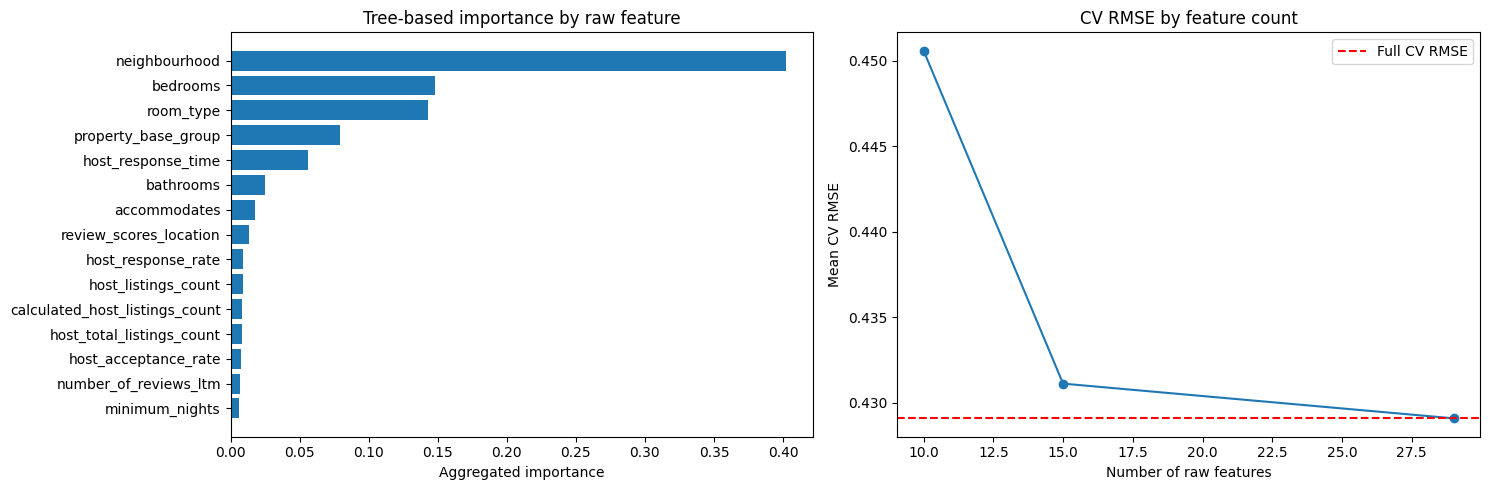

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
top_importance = tree_feature_summary.head(TOP_N_IMPORTANCE).sort_values("tree_importance")
axes[0].barh(top_importance["feature"], top_importance["tree_importance"])
axes[0].set_title("Tree-based importance by raw feature")
axes[0].set_xlabel("Aggregated importance")
axes[1].plot(feature_selection_model_summary["n_features"], feature_selection_model_summary["rmse_mean"], marker="o")
axes[1].axhline(full_rmse, color="red", linestyle="--", label="Full CV RMSE")
axes[1].set_title("CV RMSE by feature count")
axes[1].set_xlabel("Number of raw features")
axes[1].set_ylabel("Mean CV RMSE")
axes[1].legend()
fig.tight_layout()
feature_selection_chart_path = OUTPUT_DIRS["charts"] / "11_tree_feature_selection.png"
fig.savefig(feature_selection_chart_path, dpi=150, bbox_inches="tight")
plt.show()


# Hyperparameter Tuning

## 1. Cấu hình tuning

In [28]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

required_tuning_objects = [
    "X_train",
    "y_train",
    "X_test",
    "y_test",
    "all_original_features",
    "selected_features",
    "preprocessor_native_missing",
    "selected_preprocessor_native_missing",
    "feature_selection_model_summary",
]
missing_tuning_objects = [name for name in required_tuning_objects if name not in globals()]
assert not missing_tuning_objects, f"Missing required objects: {missing_tuning_objects}"
assert len(all_original_features) > 0, "all_original_features must not be empty."
assert len(selected_features) > 0, "selected_features must not be empty."
assert TARGET == "log_price", "Hyperparameter tuning expects log_price as target."
assert N_SPLITS == 5, "Hyperparameter tuning uses 5-fold CV."
assert RANDOM_STATE == 42, "Hyperparameter tuning expects RANDOM_STATE=42."
assert XGBOOST_AVAILABLE, f"XGBoost is required for tuning: {globals().get('XGBOOST_IMPORT_ERROR', '')}"

full_feature_list = list(all_original_features)
selected_feature_list = list(selected_features)

# Follow the accepted feature-selection result per model:
# HGBR keeps Full features, while XGBoost uses the Selected feature subset.
tuning_model_feature_sets = {
    "HistGradientBoostingRegressor": "Full",
    "XGBRegressor": "Selected",
}
tuning_model_features = {
    "Full": full_feature_list,
    "Selected": selected_feature_list,
}

tuning_cv = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

tuning_output_dirs = {
    "csv": OUTPUT_DIRS["csv"],
    "charts": OUTPUT_DIRS["charts"],
    "models": OUTPUT_DIRS["models"],
    "metadata": OUTPUT_DIRS["metadata"],
}
for output_dir in tuning_output_dirs.values():
    output_dir.mkdir(parents=True, exist_ok=True)

print("Full features used for HGBR tuning:", len(full_feature_list))
print("Selected features used for XGB tuning:", len(selected_feature_list))
print("Tuning model feature sets:", tuning_model_feature_sets)
print("Tuning CV:", tuning_cv)


Full features used for HGBR tuning: 29
Selected features used for XGB tuning: 15
Tuning model feature sets: {'HistGradientBoostingRegressor': 'Full', 'XGBRegressor': 'Selected'}
Tuning CV: KFold(n_splits=5, random_state=42, shuffle=True)


## 2. Hàm đánh giá cross-validation

In [29]:
def get_tuning_feature_set_name(model_key):
    return tuning_model_feature_sets[model_key]


def get_tuning_feature_list(model_key):
    return tuning_model_features[get_tuning_feature_set_name(model_key)]


def get_tuning_preprocessor_for_model(model_key):
    feature_set_name = get_tuning_feature_set_name(model_key)
    if feature_set_name == "Full":
        preprocessor = clone(preprocessor_native_missing)
    else:
        preprocessor = clone(selected_preprocessor_native_missing)

    if model_key == "HistGradientBoostingRegressor":
        preprocessor.set_params(sparse_threshold=0.0)
    return preprocessor


def calculate_regression_metrics(y_true, y_pred):
    return {
        "rmse": calculate_rmse(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
    }


def summarize_fold_metrics(fold_rows):
    fold_metrics = pd.DataFrame(fold_rows)
    return {
        "best_cv_rmse": fold_metrics["rmse"].mean(),
        "best_cv_mae": fold_metrics["mae"].mean(),
        "best_cv_r2": fold_metrics["r2"].mean(),
        "cv_rmse_std": fold_metrics["rmse"].std(ddof=1),
        "mean_fit_time": fold_metrics["fit_time_seconds"].mean(),
        "mean_best_iteration": fold_metrics["best_iteration"].dropna().mean()
        if "best_iteration" in fold_metrics else np.nan,
    }


def build_hgbr_model(params):
    supported_params = HistGradientBoostingRegressor().get_params().keys()
    base_params = {
        "early_stopping": True,
        "validation_fraction": 0.1,
        "n_iter_no_change": HGB_N_ITER_NO_CHANGE,
        "tol": 1e-4,
        "max_iter": HGB_MAX_ITER,
        "random_state": RANDOM_STATE,
    }
    model_params = {**base_params, **params}
    model_params = {key: value for key, value in model_params.items() if key in supported_params}
    return HistGradientBoostingRegressor(**model_params)


def build_xgb_model(params, *, n_estimators=XGB_MAX_ESTIMATORS, early_stopping=True):
    model_params = {
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "tree_method": "hist",
        "n_estimators": n_estimators,
        "random_state": RANDOM_STATE,
        "n_jobs": N_JOBS,
        **params,
    }
    if early_stopping:
        model_params["early_stopping_rounds"] = EARLY_STOPPING_ROUNDS
    return XGBRegressor(**model_params)


def get_xgb_best_iteration(model):
    best_iteration = getattr(model, "best_iteration", None)
    if best_iteration is None:
        booster = model.get_booster()
        best_iteration = getattr(booster, "best_iteration", None)
    if best_iteration is None:
        return np.nan
    return int(best_iteration)


def get_trial_fold_rows(trial, model_name):
    return trial.user_attrs.get(f"{model_name}_fold_rows", [])


## 3. Tuning HistGradientBoostingRegressor

In [30]:
def suggest_hgbr_params(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.20, log=True),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 15, 63),
        "max_depth": trial.suggest_categorical("max_depth", [None, 4, 6, 8, 10, 12]),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 60),
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-4, 10.0, log=True),
        "max_bins": trial.suggest_categorical("max_bins", [63, 127, 255]),
    }


def objective_hgbr(trial):
    model_name = "HistGradientBoostingRegressor"
    feature_set_name = get_tuning_feature_set_name(model_name)
    model_feature_list = get_tuning_feature_list(model_name)
    params = suggest_hgbr_params(trial)
    fold_rows = []
    rmse_values = []

    for fold_index, (train_index, validation_index) in enumerate(tuning_cv.split(X_train, y_train), start=1):
        X_fold_train = X_train.iloc[train_index][model_feature_list]
        X_fold_validation = X_train.iloc[validation_index][model_feature_list]
        y_fold_train = y_train.iloc[train_index]
        y_fold_validation = y_train.iloc[validation_index]

        preprocessor = get_tuning_preprocessor_for_model(model_name)
        model = build_hgbr_model(params)

        fit_start = time.perf_counter()
        X_fold_train_transformed = preprocessor.fit_transform(X_fold_train)
        X_fold_validation_transformed = preprocessor.transform(X_fold_validation)
        model.fit(X_fold_train_transformed, y_fold_train)
        fit_time = time.perf_counter() - fit_start

        y_pred = model.predict(X_fold_validation_transformed)
        metrics = calculate_regression_metrics(y_fold_validation, y_pred)
        rmse_values.append(metrics["rmse"])

        fold_rows.append({
            "model": model_name,
            "feature_set": feature_set_name,
            "trial_number": trial.number,
            "fold": fold_index,
            "rmse": metrics["rmse"],
            "mae": metrics["mae"],
            "r2": metrics["r2"],
            "fit_time_seconds": fit_time,
            "best_iteration": getattr(model, "n_iter_", np.nan),
        })

        current_mean_rmse = float(np.mean(rmse_values))
        trial.report(current_mean_rmse, step=fold_index)
        if trial.should_prune():
            trial.set_user_attr("HistGradientBoostingRegressor_fold_rows", fold_rows)
            raise optuna.TrialPruned()

    trial.set_user_attr("HistGradientBoostingRegressor_fold_rows", fold_rows)
    trial.set_user_attr("best_cv_mae", float(np.mean([row["mae"] for row in fold_rows])))
    trial.set_user_attr("best_cv_r2", float(np.mean([row["r2"] for row in fold_rows])))
    trial.set_user_attr("cv_rmse_std", float(np.std(rmse_values, ddof=1)))
    trial.set_user_attr("mean_fit_time", float(np.mean([row["fit_time_seconds"] for row in fold_rows])))
    trial.set_user_attr("mean_best_iteration", float(np.nanmean([row["best_iteration"] for row in fold_rows])))
    return float(np.mean(rmse_values))


hgbr_tuning_start = time.perf_counter()
hgbr_study = optuna.create_study(
    study_name="hgbr_full_rmse",
    direction="minimize",
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=2),
)
hgbr_study.optimize(
    objective_hgbr,
    n_trials=N_TRIALS_HGBR,
    timeout=TUNING_TIMEOUT,
    n_jobs=1,
    show_progress_bar=True,
)
hgbr_tuning_time_seconds = time.perf_counter() - hgbr_tuning_start
hgbr_best_fold_rows = get_trial_fold_rows(hgbr_study.best_trial, "HistGradientBoostingRegressor")
hgbr_best_fold_results = pd.DataFrame(hgbr_best_fold_rows)

print("Best HGBR feature set:", get_tuning_feature_set_name("HistGradientBoostingRegressor"))
print("Best HGBR CV RMSE:", round(hgbr_study.best_value, 6))
print("Best HGBR params:", hgbr_study.best_params)
print("Completed trials:", sum(trial.state == optuna.trial.TrialState.COMPLETE for trial in hgbr_study.trials))
print("Pruned trials:", sum(trial.state == optuna.trial.TrialState.PRUNED for trial in hgbr_study.trials))
print("Tuning time seconds:", round(hgbr_tuning_time_seconds, 2))
print("Best trial fold RMSE:", hgbr_best_fold_results["rmse"].round(6).tolist())


  0%|          | 0/30 [00:00<?, ?it/s]

Best HGBR feature set: Full
Best HGBR CV RMSE: 0.430618
Best HGBR params: {'learning_rate': 0.1317609852838106, 'max_leaf_nodes': 57, 'max_depth': None, 'min_samples_leaf': 17, 'l2_regularization': 0.00011515414867394198, 'max_bins': 255}
Completed trials: 25
Pruned trials: 5
Tuning time seconds: 827.23
Best trial fold RMSE: [0.451684, 0.408443, 0.444719, 0.427842, 0.4204]


## 4. Tuning XGBRegressor

In [31]:
def suggest_xgb_params(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 15),
        "subsample": trial.suggest_float("subsample", 0.60, 1.00),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.60, 1.00),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 20.0, log=True),
    }


def objective_xgb(trial):
    model_name = "XGBRegressor"
    feature_set_name = get_tuning_feature_set_name(model_name)
    model_feature_list = get_tuning_feature_list(model_name)
    params = suggest_xgb_params(trial)
    fold_rows = []
    rmse_values = []

    for fold_index, (train_index, validation_index) in enumerate(tuning_cv.split(X_train, y_train), start=1):
        X_fold_train = X_train.iloc[train_index][model_feature_list]
        X_fold_validation = X_train.iloc[validation_index][model_feature_list]
        y_fold_train = y_train.iloc[train_index]
        y_fold_validation = y_train.iloc[validation_index]

        preprocessor = get_tuning_preprocessor_for_model(model_name)
        fit_start = time.perf_counter()
        X_fold_train_transformed = preprocessor.fit_transform(X_fold_train)
        X_fold_validation_transformed = preprocessor.transform(X_fold_validation)

        model = build_xgb_model(params)
        model.fit(
            X_fold_train_transformed,
            y_fold_train,
            eval_set=[(X_fold_validation_transformed, y_fold_validation)],
            verbose=False,
        )
        fit_time = time.perf_counter() - fit_start

        y_pred = model.predict(X_fold_validation_transformed)
        metrics = calculate_regression_metrics(y_fold_validation, y_pred)
        rmse_values.append(metrics["rmse"])
        best_iteration = get_xgb_best_iteration(model)

        fold_rows.append({
            "model": model_name,
            "feature_set": feature_set_name,
            "trial_number": trial.number,
            "fold": fold_index,
            "rmse": metrics["rmse"],
            "mae": metrics["mae"],
            "r2": metrics["r2"],
            "fit_time_seconds": fit_time,
            "best_iteration": best_iteration,
            "best_n_estimators": best_iteration + 1 if not np.isnan(best_iteration) else np.nan,
        })

        current_mean_rmse = float(np.mean(rmse_values))
        trial.report(current_mean_rmse, step=fold_index)
        if trial.should_prune():
            trial.set_user_attr("XGBRegressor_fold_rows", fold_rows)
            raise optuna.TrialPruned()

    trial.set_user_attr("XGBRegressor_fold_rows", fold_rows)
    trial.set_user_attr("best_cv_mae", float(np.mean([row["mae"] for row in fold_rows])))
    trial.set_user_attr("best_cv_r2", float(np.mean([row["r2"] for row in fold_rows])))
    trial.set_user_attr("cv_rmse_std", float(np.std(rmse_values, ddof=1)))
    trial.set_user_attr("mean_fit_time", float(np.mean([row["fit_time_seconds"] for row in fold_rows])))
    trial.set_user_attr("mean_best_iteration", float(np.nanmean([row["best_iteration"] for row in fold_rows])))
    return float(np.mean(rmse_values))


xgb_tuning_start = time.perf_counter()
xgb_study = optuna.create_study(
    study_name="xgb_selected_rmse",
    direction="minimize",
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=2),
)
xgb_study.optimize(
    objective_xgb,
    n_trials=N_TRIALS_XGB,
    timeout=TUNING_TIMEOUT,
    n_jobs=1,
    show_progress_bar=True,
)
xgb_tuning_time_seconds = time.perf_counter() - xgb_tuning_start
xgb_best_fold_rows = get_trial_fold_rows(xgb_study.best_trial, "XGBRegressor")
xgb_best_fold_results = pd.DataFrame(xgb_best_fold_rows)

print("Best XGB feature set:", get_tuning_feature_set_name("XGBRegressor"))
print("Best XGB CV RMSE:", round(xgb_study.best_value, 6))
print("Best XGB params:", xgb_study.best_params)
print("Completed trials:", sum(trial.state == optuna.trial.TrialState.COMPLETE for trial in xgb_study.trials))
print("Pruned trials:", sum(trial.state == optuna.trial.TrialState.PRUNED for trial in xgb_study.trials))
print("Tuning time seconds:", round(xgb_tuning_time_seconds, 2))
print("Best trial fold RMSE:", xgb_best_fold_results["rmse"].round(6).tolist())


  0%|          | 0/30 [00:00<?, ?it/s]

Best XGB feature set: Selected
Best XGB CV RMSE: 0.418591
Best XGB params: {'learning_rate': 0.034246398779081366, 'max_depth': 8, 'min_child_weight': 4, 'subsample': 0.7650915513722765, 'colsample_bytree': 0.8207240159340592, 'gamma': 0.03262752834716495, 'reg_alpha': 0.001997728480368332, 'reg_lambda': 0.01363366782252473}
Completed trials: 13
Pruned trials: 17
Tuning time seconds: 952.81
Best trial fold RMSE: [0.439917, 0.390846, 0.427785, 0.420659, 0.413747]


## 5. Tổng hợp kết quả tuning

In [32]:
def study_trials_to_dataframe(study, model_name):
    rows = []
    for trial in study.trials:
        row = {
            "model": model_name,
            "feature_set": get_tuning_feature_set_name(model_name),
            "trial_number": trial.number,
            "state": trial.state.name,
            "value": trial.value,
            "duration_seconds": trial.duration.total_seconds() if trial.duration else np.nan,
            **trial.params,
        }
        row.update(trial.user_attrs)
        rows.append(row)
    return pd.DataFrame(rows)


def get_baseline_rmse(model_name, feature_set_name):
    if "feature_selection_model_summary" not in globals() or feature_selection_model_summary.empty:
        return np.nan
    baseline_rows = feature_selection_model_summary.query(
        "model == @model_name and feature_set == @feature_set_name"
    )
    if baseline_rows.empty:
        return np.nan
    return float(baseline_rows.iloc[0]["rmse_mean"])


def build_study_summary_row(study, model_name, tuning_time_seconds):
    feature_set_name = get_tuning_feature_set_name(model_name)
    best_trial = study.best_trial
    fold_results = pd.DataFrame(get_trial_fold_rows(best_trial, model_name))
    summary = summarize_fold_metrics(fold_results)
    baseline_rmse = get_baseline_rmse(model_name, feature_set_name)
    rmse_improvement = baseline_rmse - summary["best_cv_rmse"] if not np.isnan(baseline_rmse) else np.nan
    return {
        "model": model_name,
        "feature_set": feature_set_name,
        "n_trials": len(study.trials),
        "completed_trials": sum(trial.state == optuna.trial.TrialState.COMPLETE for trial in study.trials),
        "pruned_trials": sum(trial.state == optuna.trial.TrialState.PRUNED for trial in study.trials),
        **summary,
        "best_params": best_trial.params,
        "tuning_time_seconds": tuning_time_seconds,
        "baseline_rmse": baseline_rmse,
        "rmse_improvement": rmse_improvement,
        "rmse_improvement_pct": rmse_improvement / baseline_rmse if baseline_rmse and not np.isnan(baseline_rmse) else np.nan,
    }


hgbr_trials = study_trials_to_dataframe(hgbr_study, "HistGradientBoostingRegressor")
xgb_trials = study_trials_to_dataframe(xgb_study, "XGBRegressor")

save_dataframe(hgbr_trials, "10_hgbr_optuna_trials.csv")
save_dataframe(xgb_trials, "11_xgb_optuna_trials.csv")

tuning_summary = pd.DataFrame([
    build_study_summary_row(hgbr_study, "HistGradientBoostingRegressor", hgbr_tuning_time_seconds),
    build_study_summary_row(xgb_study, "XGBRegressor", xgb_tuning_time_seconds),
])

tuning_summary_display = tuning_summary.copy()
tuning_summary_display["best_params"] = tuning_summary_display["best_params"].apply(json.dumps)
save_dataframe(tuning_summary_display, "12_tuning_summary.csv")
tuning_summary


Saved: ml/outputs/price_modeling/csv/10_hgbr_optuna_trials.csv
Saved: ml/outputs/price_modeling/csv/11_xgb_optuna_trials.csv
Saved: ml/outputs/price_modeling/csv/12_tuning_summary.csv


,model,feature_set,n_trials,completed_trials,pruned_trials,best_cv_rmse,best_cv_mae,best_cv_r2,cv_rmse_std,mean_fit_time,mean_best_iteration,best_params,tuning_time_seconds,baseline_rmse,rmse_improvement,rmse_improvement_pct
0,HistGradientBoostingRegressor,Full,30,25,5,0.430618,0.282792,0.682555,0.017653,5.685671,200.8,"{'learning_rate': 0.1317609852838106, 'max_lea...",827.231893,NaN,NaN,NaN
1,XGBRegressor,Selected,30,13,17,0.418591,0.270297,0.700057,0.018282,13.351299,974.6,"{'learning_rate': 0.034246398779081366, 'max_d...",952.811189,NaN,NaN,NaN


## 6. Chọn mô hình tốt nhất theo CV RMSE

In [33]:
selection_tolerance = 1e-6
candidate_tuning_summary = tuning_summary.sort_values(
    ["best_cv_rmse", "cv_rmse_std", "mean_fit_time", "model"],
    ascending=[True, True, True, True],
).reset_index(drop=True)

best_tuned_model_row = candidate_tuning_summary.iloc[0]
best_tuned_model_name = best_tuned_model_row["model"]
best_tuned_params = best_tuned_model_row["best_params"]

if best_tuned_model_name == "HistGradientBoostingRegressor":
    best_tuned_study = hgbr_study
    best_tuned_cv_folds = hgbr_best_fold_results.copy()
else:
    best_tuned_study = xgb_study
    best_tuned_cv_folds = xgb_best_fold_results.copy()

save_dataframe(best_tuned_cv_folds, "13_best_tuned_cv_folds.csv")
print("Best tuned model:", best_tuned_model_name)
print("Best CV RMSE:", round(best_tuned_model_row["best_cv_rmse"], 6))
print("Best params:", best_tuned_params)


Saved: ml/outputs/price_modeling/csv/13_best_tuned_cv_folds.csv
Best tuned model: XGBRegressor
Best CV RMSE: 0.418591
Best params: {'learning_rate': 0.034246398779081366, 'max_depth': 8, 'min_child_weight': 4, 'subsample': 0.7650915513722765, 'colsample_bytree': 0.8207240159340592, 'gamma': 0.03262752834716495, 'reg_alpha': 0.001997728480368332, 'reg_lambda': 0.01363366782252473}


## 7. Huấn luyện mô hình cuối cùng

In [34]:
best_tuned_feature_set = best_tuned_model_row["feature_set"]
final_feature_list = get_tuning_feature_list(best_tuned_model_name)
final_preprocessor = get_tuning_preprocessor_for_model(best_tuned_model_name)
X_train_final = X_train[final_feature_list]
X_test_final = X_test[final_feature_list]

final_fit_start = time.perf_counter()

if best_tuned_model_name == "HistGradientBoostingRegressor":
    final_model = build_hgbr_model(best_tuned_params)
    final_pipeline = Pipeline(steps=[
        ("preprocessor", final_preprocessor),
        ("model", final_model),
    ])
    final_pipeline.fit(X_train_final, y_train)
    final_iteration_value = getattr(final_pipeline.named_steps["model"], "n_iter_", np.nan)
    final_n_estimators = np.nan
else:
    best_n_estimators_per_fold = best_tuned_cv_folds["best_n_estimators"].dropna().to_numpy()
    assert len(best_n_estimators_per_fold) > 0, "XGB best_n_estimators from CV must be available."
    final_n_estimators = int(np.median(best_n_estimators_per_fold))
    final_model = build_xgb_model(
        best_tuned_params,
        n_estimators=final_n_estimators,
        early_stopping=False,
    )
    final_pipeline = Pipeline(steps=[
        ("preprocessor", final_preprocessor),
        ("model", final_model),
    ])
    final_pipeline.fit(X_train_final, y_train)
    final_iteration_value = final_n_estimators

final_fit_time_seconds = time.perf_counter() - final_fit_start

final_model_artifact = {
    "model_name": best_tuned_model_name,
    "feature_set": best_tuned_feature_set,
    "model_features": final_feature_list,
    "selected_features": selected_feature_list,
    "pipeline": final_pipeline,
    "target_transform": "log1p",
    "inverse_transform": "expm1",
}

print("Final model:", best_tuned_model_name)
print("Final feature set:", best_tuned_feature_set)
print("Final fit time seconds:", round(final_fit_time_seconds, 2))
print("Final iteration/tree count:", final_iteration_value)


Final model: XGBRegressor
Final feature set: Selected
Final fit time seconds: 7.97
Final iteration/tree count: 1007


## 8. Đánh giá duy nhất trên tập test

In [35]:
predicted_log_price = final_pipeline.predict(X_test_final)
actual_log_price = y_test.to_numpy()

final_test_metrics = {
    "model": best_tuned_model_name,
    "feature_set": best_tuned_feature_set,
    "rmse_log": calculate_rmse(actual_log_price, predicted_log_price),
    "mae_log": mean_absolute_error(actual_log_price, predicted_log_price),
    "r2_log": r2_score(actual_log_price, predicted_log_price),
}

actual_price = np.expm1(actual_log_price)
predicted_price = np.maximum(np.expm1(predicted_log_price), 0)
final_test_metrics["rmse_price"] = calculate_rmse(actual_price, predicted_price)
final_test_metrics["mae_price"] = mean_absolute_error(actual_price, predicted_price)

final_test_metrics_df = pd.DataFrame([final_test_metrics])

final_test_predictions = pd.DataFrame({
    "actual_log_price": actual_log_price,
    "predicted_log_price": predicted_log_price,
    "residual_log": actual_log_price - predicted_log_price,
    "actual_price": actual_price,
    "predicted_price": predicted_price,
    "absolute_error_price": np.abs(actual_price - predicted_price),
}, index=y_test.index)

if "meta_test" in globals() and "listing_id" in meta_test.columns:
    final_test_predictions.insert(0, "listing_id", meta_test.loc[y_test.index, "listing_id"].to_numpy())

final_test_metrics_df


,model,feature_set,rmse_log,mae_log,r2_log,rmse_price,mae_price
0,XGBRegressor,Selected,0.384831,0.253058,0.725194,4071.276027,717.342489


## 9. Lưu kết quả và model artifact

In [36]:
best_hyperparameters = pd.DataFrame([
    {
        "model": "HistGradientBoostingRegressor",
        "feature_set": get_tuning_feature_set_name("HistGradientBoostingRegressor"),
        "best_params": json.dumps(hgbr_study.best_params),
        "best_cv_rmse": hgbr_study.best_value,
    },
    {
        "model": "XGBRegressor",
        "feature_set": get_tuning_feature_set_name("XGBRegressor"),
        "best_params": json.dumps(xgb_study.best_params),
        "best_cv_rmse": xgb_study.best_value,
    },
])

save_dataframe(final_test_metrics_df, "14_final_test_metrics.csv")
save_dataframe(final_test_predictions.reset_index(names="row_index"), "15_final_test_predictions.csv")
save_dataframe(best_hyperparameters, "16_best_hyperparameters.csv")

final_model_path = OUTPUT_DIRS["models"] / "final_price_model.joblib"
joblib.dump(final_model_artifact, final_model_path)
print(f"Saved: {format_output_path(final_model_path)}")

final_metadata = {
    "model_name": best_tuned_model_name,
    "feature_set": best_tuned_feature_set,
    "model_features": final_feature_list,
    "selected_features": selected_feature_list,
    "best_params": best_tuned_params,
    "cv_rmse": best_tuned_model_row["best_cv_rmse"],
    "cv_rmse_std": best_tuned_model_row["cv_rmse_std"],
    "test_rmse_log": final_test_metrics["rmse_log"],
    "test_mae_log": final_test_metrics["mae_log"],
    "test_r2_log": final_test_metrics["r2_log"],
    "test_rmse_price": final_test_metrics["rmse_price"],
    "test_mae_price": final_test_metrics["mae_price"],
    "final_n_estimators": final_n_estimators,
    "n_iter_": final_iteration_value if best_tuned_model_name == "HistGradientBoostingRegressor" else np.nan,
    "random_state": RANDOM_STATE,
    "target_column": TARGET,
    "target_transform": "log1p",
    "inverse_transform": "expm1",
    "created_at": datetime.now().isoformat(timespec="seconds"),
}

final_metadata_path = OUTPUT_DIRS["models"] / "final_price_model_metadata.json"
with final_metadata_path.open("w", encoding="utf-8") as file:
    json.dump(final_metadata, file, indent=4, ensure_ascii=False, default=json_default)
print(f"Saved: {format_output_path(final_metadata_path)}")


Saved: ml/outputs/price_modeling/csv/14_final_test_metrics.csv
Saved: ml/outputs/price_modeling/csv/15_final_test_predictions.csv
Saved: ml/outputs/price_modeling/csv/16_best_hyperparameters.csv
Saved: ml/outputs/price_modeling/models/final_price_model.joblib
Saved: ml/outputs/price_modeling/models/final_price_model_metadata.json


## 10. Biểu đồ

Saved: ml/outputs/price_modeling/charts/06_hgbr_optimization_history.png


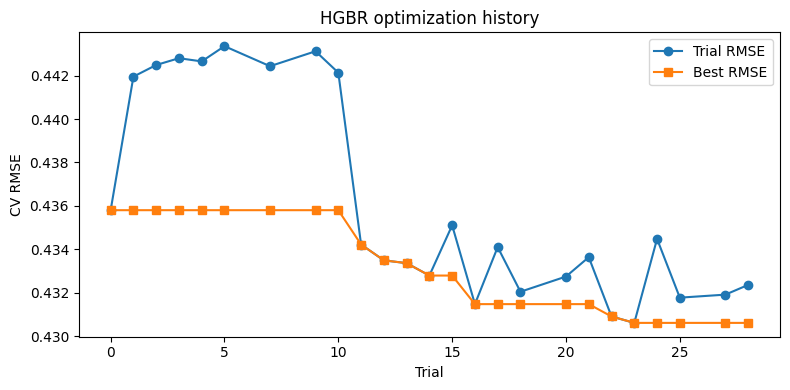

Saved: ml/outputs/price_modeling/charts/07_xgb_optimization_history.png


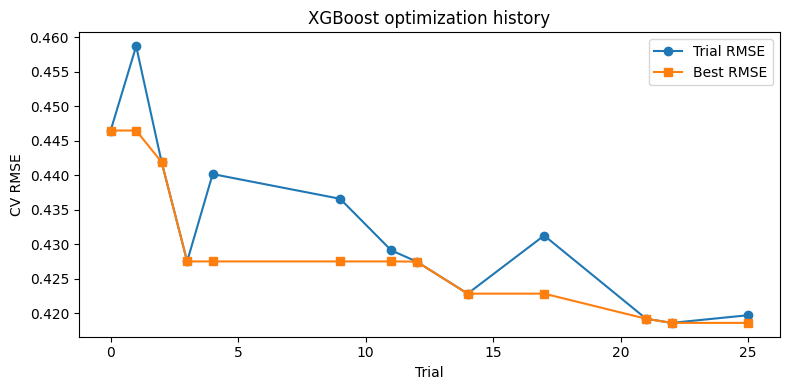

Saved: ml/outputs/price_modeling/charts/08_hgbr_parameter_importance.png


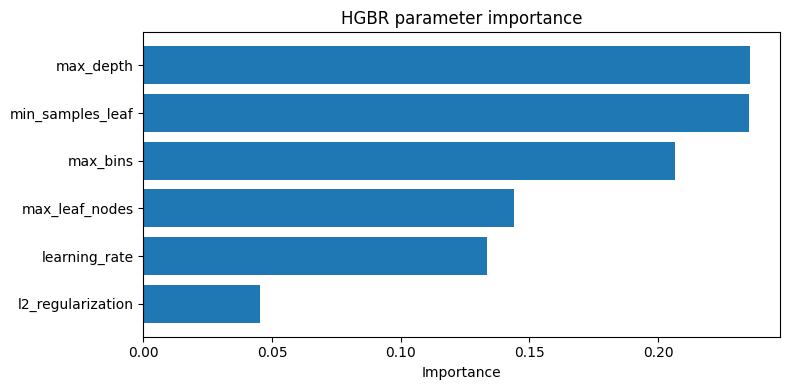

Saved: ml/outputs/price_modeling/charts/09_xgb_parameter_importance.png


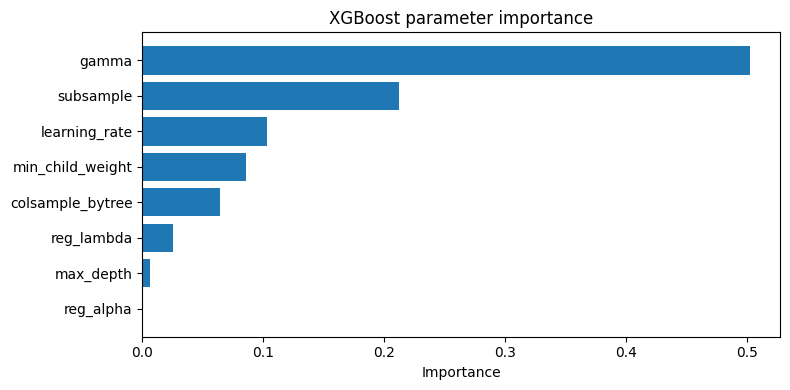

Saved: ml/outputs/price_modeling/charts/10_baseline_vs_tuned_rmse.png


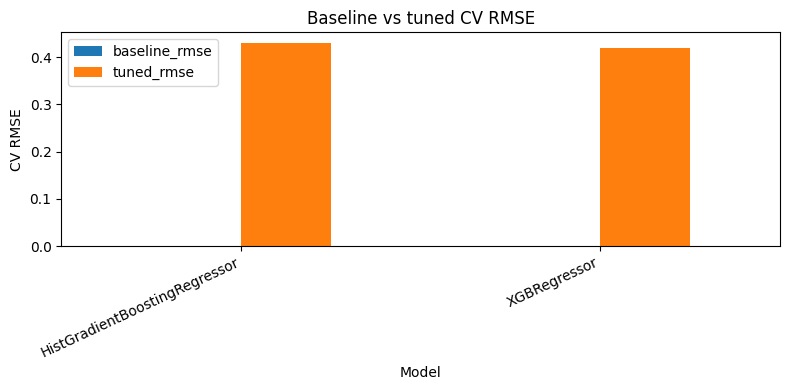

Saved: ml/outputs/price_modeling/charts/11_final_predicted_vs_actual_price.png


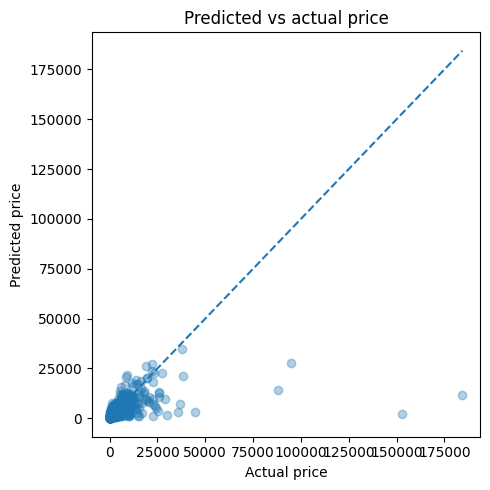

Saved: ml/outputs/price_modeling/charts/12_final_residual_distribution.png


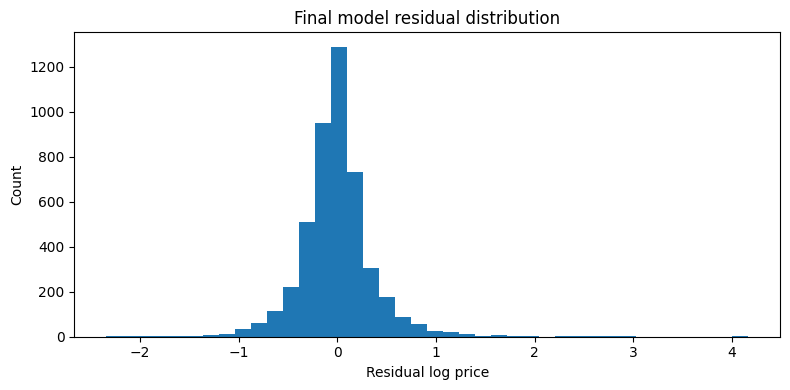

In [37]:
def save_tuning_plot(filename):
    output_path = OUTPUT_DIRS["charts"] / filename
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {format_output_path(output_path)}")
    plt.show()


def plot_optimization_history(study, title, filename):
    complete_trials = [trial for trial in study.trials if trial.state == optuna.trial.TrialState.COMPLETE]
    if not complete_trials:
        print(f"No completed trials for {title}.")
        return
    trial_numbers = [trial.number for trial in complete_trials]
    values = [trial.value for trial in complete_trials]
    best_values = np.minimum.accumulate(values)
    plt.figure(figsize=(8, 4))
    plt.plot(trial_numbers, values, marker="o", label="Trial RMSE")
    plt.plot(trial_numbers, best_values, marker="s", label="Best RMSE")
    plt.title(title)
    plt.xlabel("Trial")
    plt.ylabel("CV RMSE")
    plt.legend()
    save_tuning_plot(filename)


def plot_param_importance(study, title, filename):
    complete_trials = [trial for trial in study.trials if trial.state == optuna.trial.TrialState.COMPLETE]
    if len(complete_trials) < 2:
        print(f"Not enough completed trials for parameter importance: {title}.")
        return
    importances = get_param_importances(study)
    if not importances:
        print(f"No parameter importance available for {title}.")
        return
    importance_df = pd.DataFrame({
        "parameter": list(importances.keys()),
        "importance": list(importances.values()),
    }).sort_values("importance")
    plt.figure(figsize=(8, 4))
    plt.barh(importance_df["parameter"], importance_df["importance"])
    plt.title(title)
    plt.xlabel("Importance")
    save_tuning_plot(filename)


plot_optimization_history(hgbr_study, "HGBR optimization history", "06_hgbr_optimization_history.png")
plot_optimization_history(xgb_study, "XGBoost optimization history", "07_xgb_optimization_history.png")
plot_param_importance(hgbr_study, "HGBR parameter importance", "08_hgbr_parameter_importance.png")
plot_param_importance(xgb_study, "XGBoost parameter importance", "09_xgb_parameter_importance.png")

baseline_tuned_plot = tuning_summary[["model", "baseline_rmse", "best_cv_rmse"]].copy()
baseline_tuned_plot = baseline_tuned_plot.rename(columns={"best_cv_rmse": "tuned_rmse"})
baseline_tuned_plot = baseline_tuned_plot.set_index("model")
plt.figure(figsize=(8, 4))
baseline_tuned_plot.plot(kind="bar", ax=plt.gca())
plt.title("Baseline vs tuned CV RMSE")
plt.xlabel("Model")
plt.ylabel("CV RMSE")
plt.xticks(rotation=25, ha="right")
save_tuning_plot("10_baseline_vs_tuned_rmse.png")

plt.figure(figsize=(5, 5))
plt.scatter(actual_price, predicted_price, alpha=0.35)
price_limit = max(np.nanmax(actual_price), np.nanmax(predicted_price))
plt.plot([0, price_limit], [0, price_limit], linestyle="--")
plt.title("Predicted vs actual price")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
save_tuning_plot("11_final_predicted_vs_actual_price.png")

plt.figure(figsize=(8, 4))
plt.hist(final_test_predictions["residual_log"], bins=40)
plt.title("Final model residual distribution")
plt.xlabel("Residual log price")
plt.ylabel("Count")
save_tuning_plot("12_final_residual_distribution.png")


## Kết luận modeling

Mô hình cuối cùng và tập feature được chọn dựa trên cross-validation của train set. Test set chỉ được dùng một lần ở bước đánh giá cuối; model, metadata và dự báo test đã lưu là input cho notebook 04 và 05.

## Hoàn tất modeling

Notebook này kết thúc sau khi lưu final model, metadata và dự báo test. Phân phân tích sai số và giải thích SHAP nằm ở notebook 04 và 05.